#  Klasifikasi Diabetes Melitus menggunakan Logistic Regression
### Metodologi: CRISP-DM *(Cross Industry Standard Process for Data Mining)*

---
| Atribut | Detail |
|---|---|
| **Dataset** | `balanced_dataset.csv` (17.000 records, 9 fitur) |
| **Algoritma** | Logistic Regression |
| **Evaluasi** | Accuracy, Precision, Recall, F1-Score, AUC-ROC, 5-Fold Cross-Validation |
| **Metodologi** | CRISP-DM 6-Phase Framework |

---
## PHASE 1 — BUSINESS UNDERSTANDING

> *Memahami tujuan proyek dari perspektif bisnis/akademis, lalu mendefinisikan problem data mining.*

### Latar Belakang
Diabetes Melitus adalah penyakit kronis yang ditandai dengan kadar gula darah tinggi akibat gangguan produksi atau fungsi insulin. Deteksi dini sangat penting untuk mencegah komplikasi serius seperti gagal ginjal, kebutaan, dan penyakit jantung. Machine learning dapat membantu tenaga medis mengklasifikasikan risiko diabetes secara otomatis berdasarkan data klinis pasien.

### Business Goal
Membangun model klasifikasi yang mampu **memprediksi apakah seorang pasien menderita diabetes** berdasarkan fitur-fitur klinis (usia, BMI, HbA1c, glukosa darah, dll.).

### Data Mining Goal
- Melatih model **Logistic Regression** dengan akurasi >= 85%
- Menghasilkan evaluasi menyeluruh: Accuracy, Precision, Recall, F1-Score, AUC-ROC
- Validasi model dengan **5-Fold Cross-Validation** untuk menjamin generalisasi

### Kriteria Keberhasilan
| Metrik | Target |
|---|---|
| Accuracy | >= 85% |
| AUC-ROC | >= 0.90 |
| F1-Score | >= 0.85 |
| CV Score (mean) | >= 85% |


## 1. Import Library

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  accuracy_score, classification_report,
  confusion_matrix, ConfusionMatrixDisplay,
  roc_curve, roc_auc_score
)

print('Library berhasil di-import')

Library berhasil di-import


---
## PHASE 2 — DATA UNDERSTANDING

> *Mengumpulkan data awal, eksplorasi untuk mengenal konten, kualitas, dan wawasan pertama.*

**Langkah-langkah dalam fase ini:**
- Load dataset mentah
- EDA awal: shape, tipe data, distribusi kelas target
- Visualisasi distribusi kelas diabetes vs non-diabetes
- Info dataset setelah balancing dan distribusi fitur kategorikal
- Deteksi *Missing Value*
- Deteksi Outlier (Boxplot)


## 2. Load Dataset

In [87]:
df = pd.read_csv("/kaggle/input/datasets/vindiar/diabetes/dataset_diabetes.csv")

## 3. Exploratory Data Analysis (EDA) Sebelum Balancing

In [88]:
print("Shape data (baris, kolom):" + str(df.shape))
print(df.info())

Shape data (baris, kolom):(100000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


### Periksa Dataset

#### jumlah pasien diabetes dan non diabetes berbanding jauh

In [89]:
df['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

---
## PHASE 3 — DATA PREPARATION

> *Memilih, membersihkan, membangun, dan memformat data yang akan digunakan untuk pemodelan.*

**Langkah-langkah dalam fase ini:**
- Balancing dataset dengan *Random Undersampling* (menangani class imbalance)
- Filter atribut jenis kelamin (hanya Male dan Female)
- Proses *Cleaning Outlier* dengan metode IQR
- Analisis dan visualisasi distribusi atribut kategorikal
- *Label Encoding* — One-Hot Encoding untuk fitur kategorikal


## 4. Balancing Dataset dengan Random Undersampling

In [90]:
from sklearn.utils import resample

# Memisahkan kelas mayoritas (0: non-diabetes) dan minoritas (1: diabetes)
df_majority = df[df['diabetes'] == 0]
df_minority = df[df['diabetes'] == 1]

# Melakukan downsampling pada kelas mayoritas
df_majority_downsampled = resample(df_majority,
                               replace=False,    # tanpa pengembalian (without replacement)
                               n_samples=len(df_minority), # disamakan dengan jumlah data minoritas (8500)
                               random_state=42)  # agar hasil dapat direproduksi

# Menggabungkan kembali kelas minoritas dengan kelas mayoritas yang sudah di-downsample
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Mengacak urutan baris agar tidak berurutan (opsional)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Mengecek hasil dari penyeimbangan data
print(df_balanced['diabetes'].value_counts())

# Menyimpan dataset yang telah seimbang ke file CSV baru
df_balanced.to_csv('balanced_dataset.csv', index=False)

diabetes
1    8500
0    8500
Name: count, dtype: int64


## 5. Load Dataset Baru

In [91]:
# Membaca dataset yang sudah seimbang
df_balanced = pd.read_csv("balanced_dataset.csv")

## 6. Filter Atribut Jenis Kelamin

In [92]:
# Hanya gunakan gender Male dan Female
df_balanced = df_balanced[df_balanced['gender'].isin(['Male', 'Female'])].copy()
df_balanced.reset_index(drop=True, inplace=True)

# Menampilkan informasi
print(f'Shape data: {df_balanced.shape}')
print(f'Distribusi gender: {df_balanced["gender"].value_counts().to_dict()}')
print(df_balanced.head().to_string())

Shape data: (16998, 9)
Distribusi gender: {'Female': 9489, 'Male': 7509}
   gender   age  hypertension  heart_disease smoking_history    bmi  HbA1c_level  blood_glucose_level  diabetes
0    Male  80.0             1              0          former  27.32          8.2                  140         1
1  Female  35.0             0              0         No Info  27.32          4.5                  158         0
2  Female  55.0             1              0           never  27.32          8.8                  220         1
3    Male  68.0             0              0          former  28.19          3.5                  100         0
4  Female  26.0             0              0     not current  21.38          5.8                  155         0


## 7. Visualisasi Antara Diabetes dan Non-Diabetes

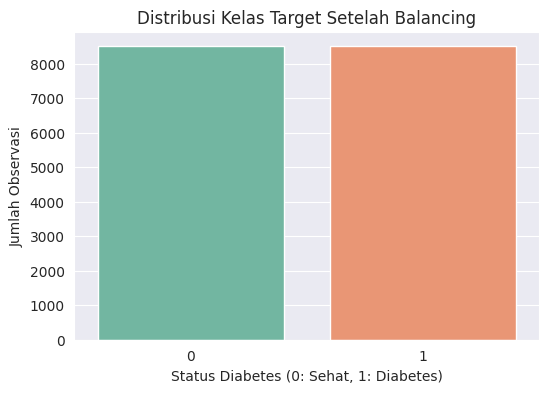

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran kanvas grafik
plt.figure(figsize=(6, 4))

# Membuat Bar Chart (Countplot)
sns.countplot(x='diabetes', data=df_balanced, palette='Set2')

# Menambahkan label dan judul
plt.title('Distribusi Kelas Target Setelah Balancing', fontsize=12)
plt.xlabel('Status Diabetes (0: Sehat, 1: Diabetes)', fontsize=10)
plt.ylabel('Jumlah Observasi', fontsize=10)

# Menampilkan grafik
plt.show()

## 8. Info Dataset Setelah Balancing

In [94]:
print('=== Info Dataset ===')
df_balanced.info()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16998 entries, 0 to 16997
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               16998 non-null  object 
 1   age                  16998 non-null  float64
 2   hypertension         16998 non-null  int64  
 3   heart_disease        16998 non-null  int64  
 4   smoking_history      16998 non-null  object 
 5   bmi                  16998 non-null  float64
 6   HbA1c_level          16998 non-null  float64
 7   blood_glucose_level  16998 non-null  int64  
 8   diabetes             16998 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 1.2+ MB


In [95]:
df_balanced.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000
mean,50.665412,0.151488,0.088305,29.427427,6.163766,163.245264,0.500059
std,21.445955,0.358535,0.283746,7.392769,1.283926,56.973886,0.500015
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,36.000000,0.000000,0.000000,25.890000,5.700000,130.000000,0.000000
50%,54.000000,0.000000,0.000000,27.320000,6.100000,155.000000,1.000000
75%,67.000000,0.000000,0.000000,32.770000,6.600000,200.000000,1.000000
max,80.000000,1.000000,1.000000,88.720000,9.000000,300.000000,1.000000


## 9. Distribusi Fitur Kategorikal Setelah Balancing

In [96]:
print('=== Distribusi Fitur Kategorikal (Setelah Balancing) ===')
for col in df_balanced.select_dtypes(include=['object', 'category']).columns:
  print(f'\n{col}:')
  print(df_balanced[col].value_counts())

=== Distribusi Fitur Kategorikal (Setelah Balancing) ===

gender:
gender
Female    9489
Male      7509
Name: count, dtype: int64

smoking_history:
smoking_history
never          6288
No Info        4680
former         2317
current        1710
not current    1217
ever            786
Name: count, dtype: int64


In [97]:
df_balanced.groupby('gender')['diabetes'].value_counts()

gender  diabetes
Female  0           5028
        1           4461
Male    1           4039
        0           3470
Name: count, dtype: int64

## 10. Mencari *Missing Value*

=== Jumlah Missing Value ===
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


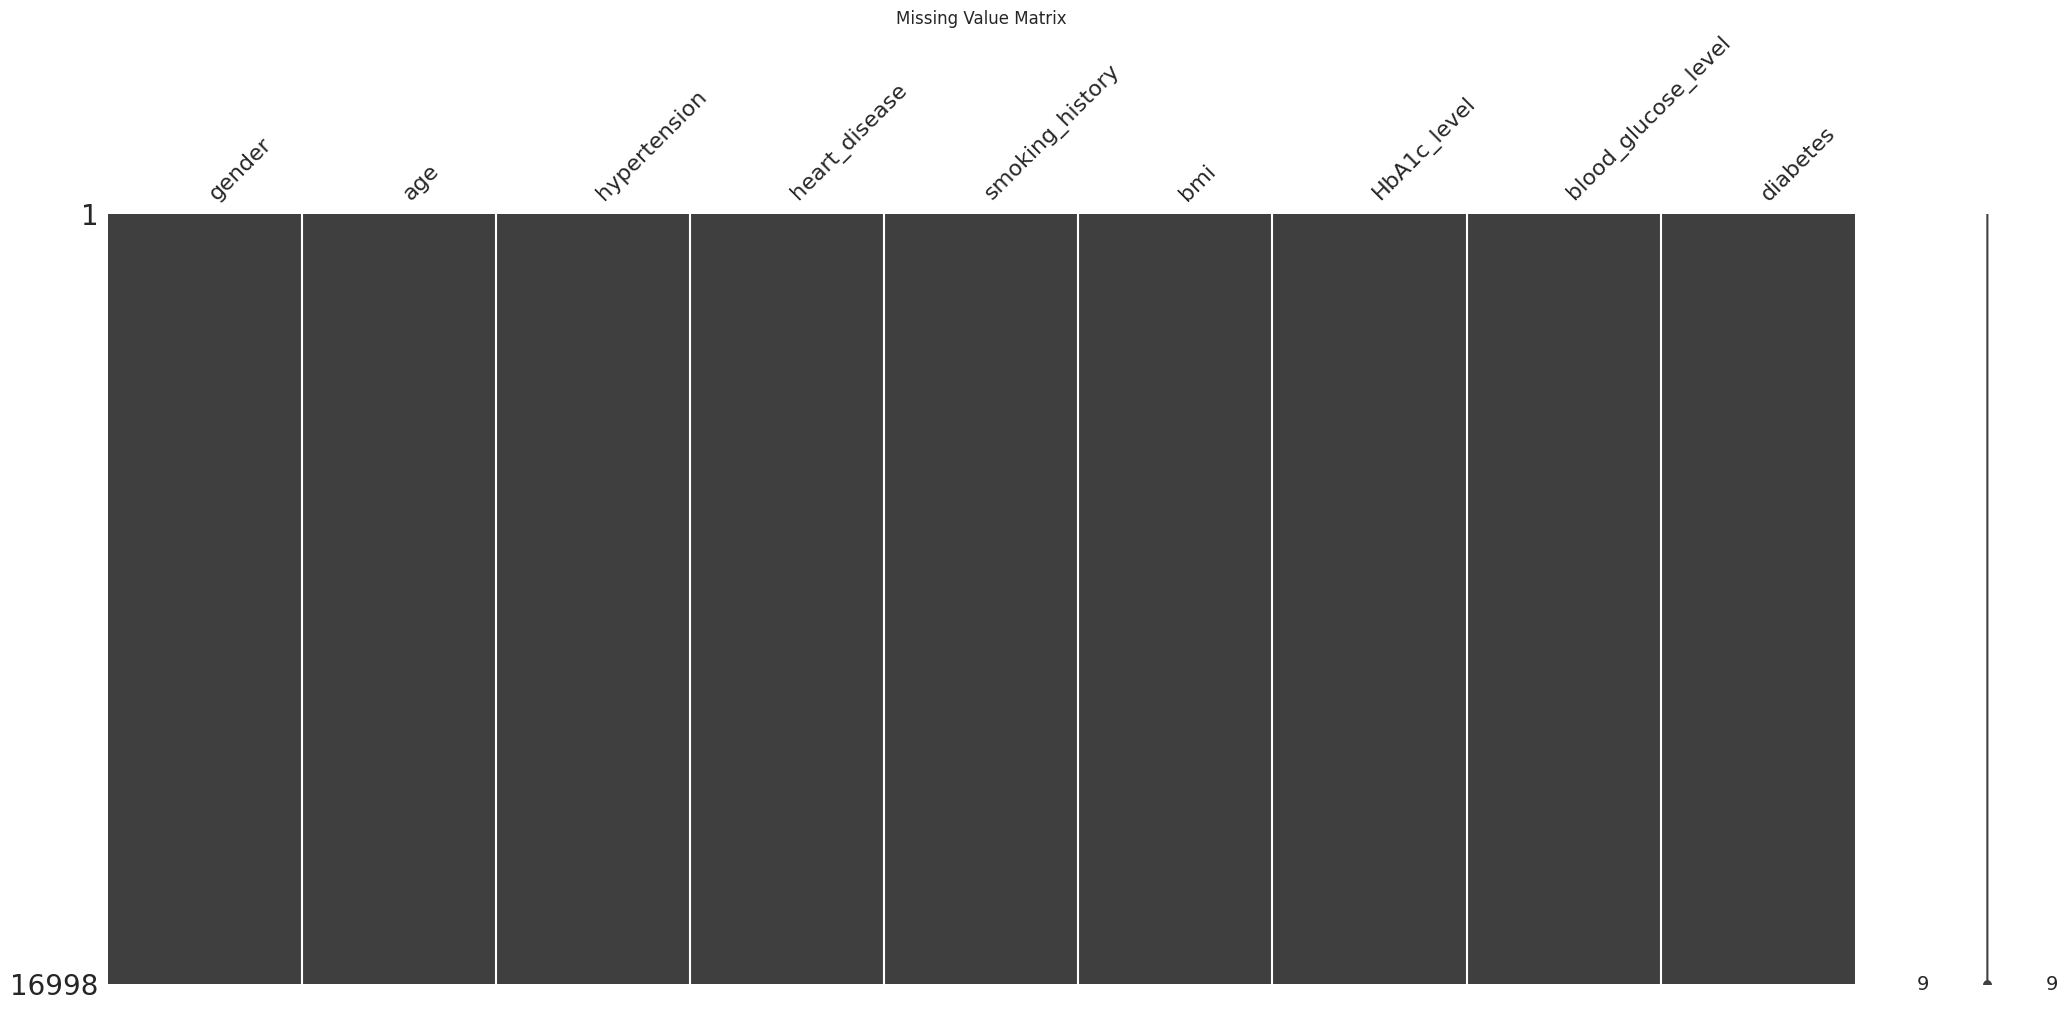

In [98]:
print('=== Jumlah Missing Value ===')
print(df_balanced.isnull().sum())

# Membuat visualisasi missing value
msno.matrix(df_balanced)
plt.title('Missing Value Matrix')
plt.show()

## 11. Boxplot sebelum Cleaning Outlier

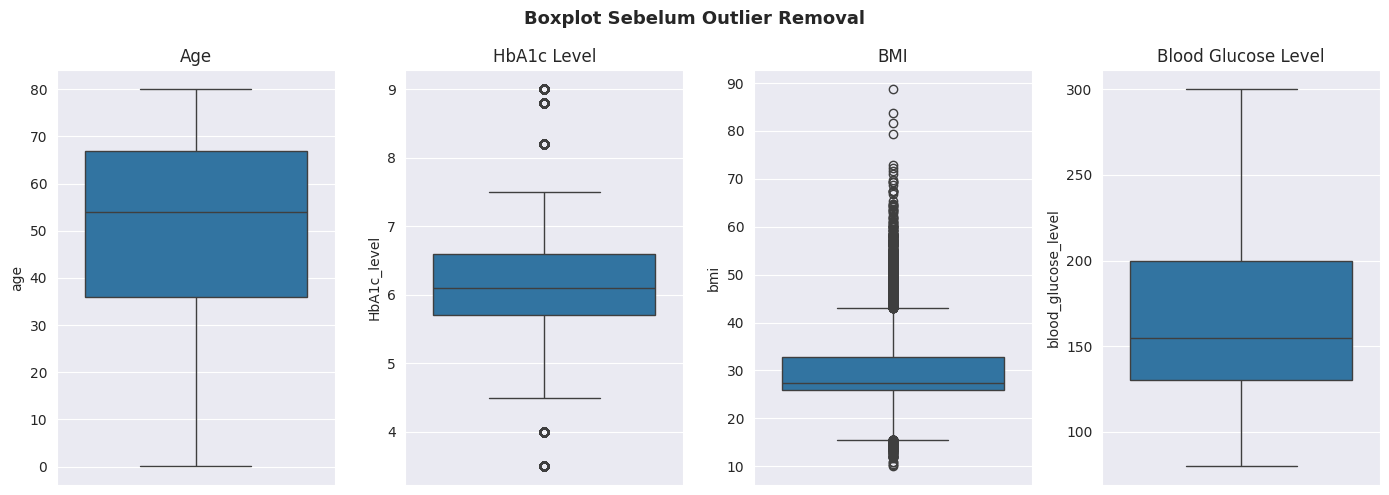

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

sns.boxplot(ax=axes[0], data=df_balanced['age'])
axes[0].set_title('Age')

sns.boxplot(ax=axes[1], data=df_balanced['HbA1c_level'])
axes[1].set_title('HbA1c Level')

sns.boxplot(ax=axes[2], data=df_balanced['bmi'])
axes[2].set_title('BMI')

sns.boxplot(ax=axes[3], data=df_balanced['blood_glucose_level'])
axes[3].set_title('Blood Glucose Level')

plt.suptitle('Boxplot Sebelum Outlier Removal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Proses Cleaning Outlier

In [100]:
num_cols = ['HbA1c_level', 'bmi', 'blood_glucose_level']

Q1 = df_balanced[num_cols].quantile(0.25)
Q3 = df_balanced[num_cols].quantile(0.75)
IQR = Q3 - Q1

mask = pd.Series([True] * len(df_balanced), index=df_balanced.index)
for col in num_cols:
  lower = Q1[col] - 1.5 * IQR[col]
  upper = Q3[col] + 1.5 * IQR[col]
  mask = mask & (df_balanced[col] >= lower) & (df_balanced[col] <= upper)

data_clean = df_balanced.loc[mask].copy()
data_clean.reset_index(drop=True, inplace=True)

print(f'Baris sebelum : {len(df_balanced)}')
print(f'Baris setelah : {len(data_clean)}')
print(f'Outlier dihapus: {len(df_balanced) - len(data_clean)} ({(len(df_balanced)-len(data_clean))/len(df_balanced)*100:.1f}%)')

Baris sebelum : 16998
Baris setelah : 12680
Outlier dihapus: 4318 (25.4%)


### Boxplot Setelah Cleaning Outlier

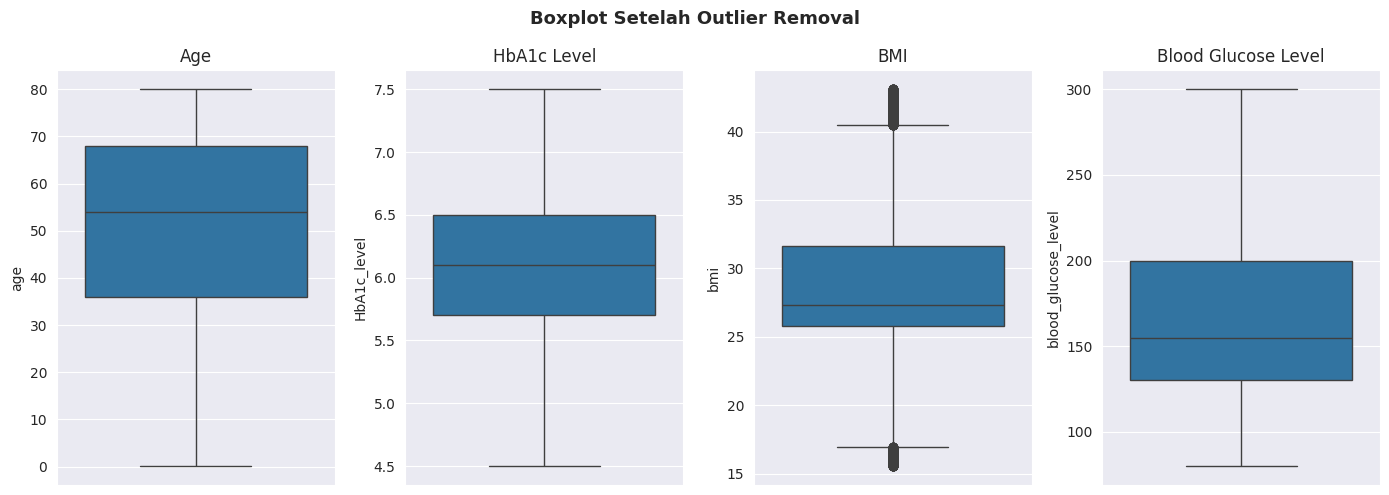

In [101]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

sns.boxplot(ax=axes[0], data=data_clean['age'])
axes[0].set_title('Age')

sns.boxplot(ax=axes[1], data=data_clean['HbA1c_level'])
axes[1].set_title('HbA1c Level')

sns.boxplot(ax=axes[2], data=data_clean['bmi'])
axes[2].set_title('BMI')

sns.boxplot(ax=axes[3], data=data_clean['blood_glucose_level'])
axes[3].set_title('Blood Glucose Level')

plt.suptitle('Boxplot Setelah Outlier Removal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Analisis Distribusi Atribut Kategorikal

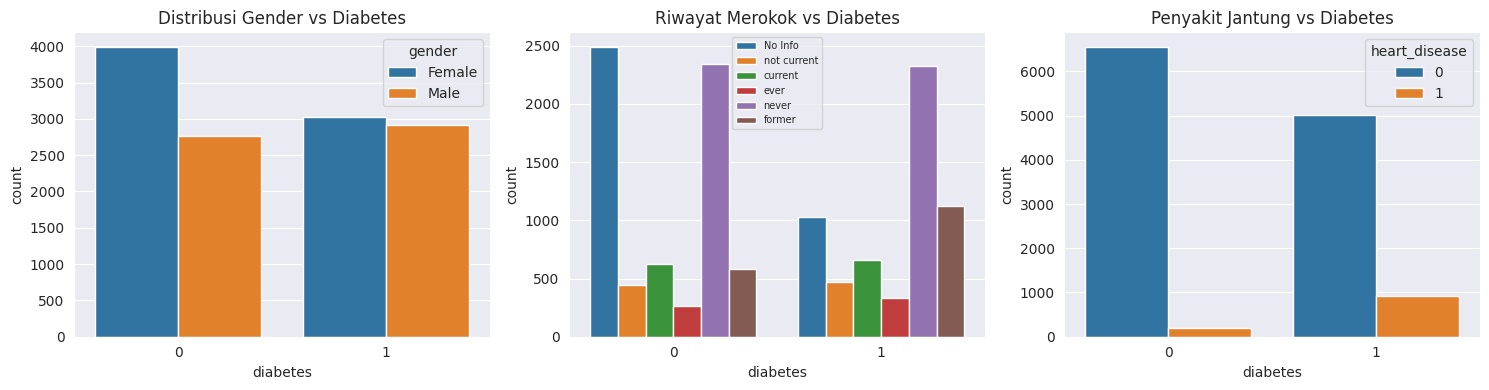

In [102]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(ax=axes[0], x='diabetes', data=data_clean, hue='gender')
axes[0].set_title('Distribusi Gender vs Diabetes')

sns.countplot(ax=axes[1], x='diabetes', data=data_clean, hue='smoking_history')
axes[1].set_title('Riwayat Merokok vs Diabetes')
axes[1].legend(fontsize=7)

sns.countplot(ax=axes[2], x='diabetes', data=data_clean, hue='heart_disease')
axes[2].set_title('Penyakit Jantung vs Diabetes')

plt.tight_layout()
plt.show()

## 13. Visualisasi Distribusi Fitur Kategorikal

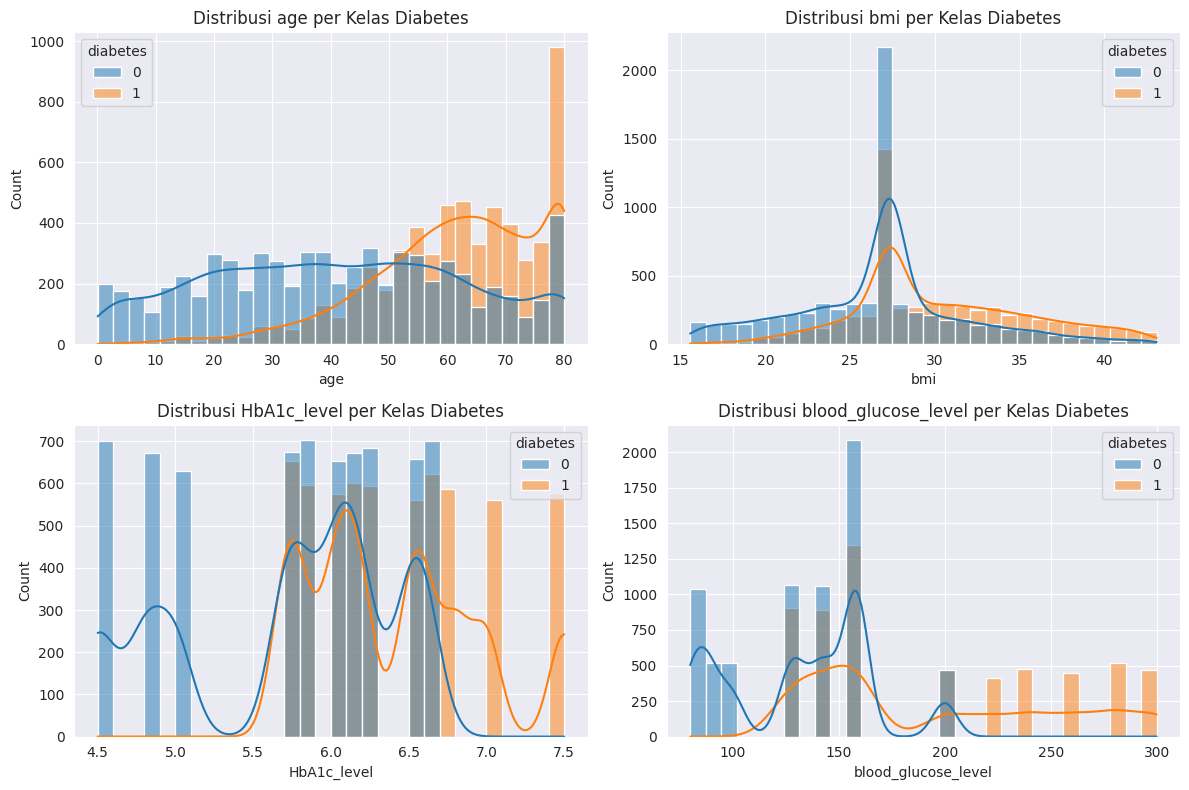

In [103]:
# Distribusi fitur numerik
num_feats = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(num_feats):
  sns.histplot(data=data_clean, x=feat, hue='diabetes',
               kde=True, ax=axes[i], bins=30)
  axes[i].set_title(f'Distribusi {feat} per Kelas Diabetes')

plt.tight_layout()
plt.show()

## 14. Label Encoding (One-Hot Encoding)

In [104]:
df_encoded = data_clean.copy()

# One-Hot Encoding untuk kolom nominal
df_encoded = pd.get_dummies(df_encoded, columns=['gender', 'smoking_history'], drop_first=True)

print('Kolom setelah encoding:')
print(df_encoded.columns.tolist())
print(f'\nShape: {df_encoded.shape}')
df_encoded.head()

Kolom setelah encoding:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']

Shape: (12680, 13)


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,35.0,0,0,27.32,4.5,158,0,False,False,False,False,False,False
1,26.0,0,0,21.38,5.8,155,0,False,False,False,False,False,True
2,3.0,0,0,18.52,6.2,85,0,True,False,False,False,False,False
3,80.0,0,0,27.32,6.0,280,1,False,False,False,False,True,False
4,57.0,0,1,40.52,6.0,126,1,True,False,False,False,True,False


---
## PHASE 4 — MODELING

> *Memilih dan menerapkan teknik pemodelan, mengkalibrasi parameter, dan melatih model.*

**Langkah-langkah dalam fase ini:**
- Analisis korelasi antar fitur (Heatmap) — seleksi fitur relevan
- *Data Splitting* — Train/Test Split (80:20, stratified)
- *Data Scaling* — Standardisasi fitur dengan `StandardScaler`
- Pelatihan model **Logistic Regression**


## 15. Heatmap Korelasi Antar Fitur

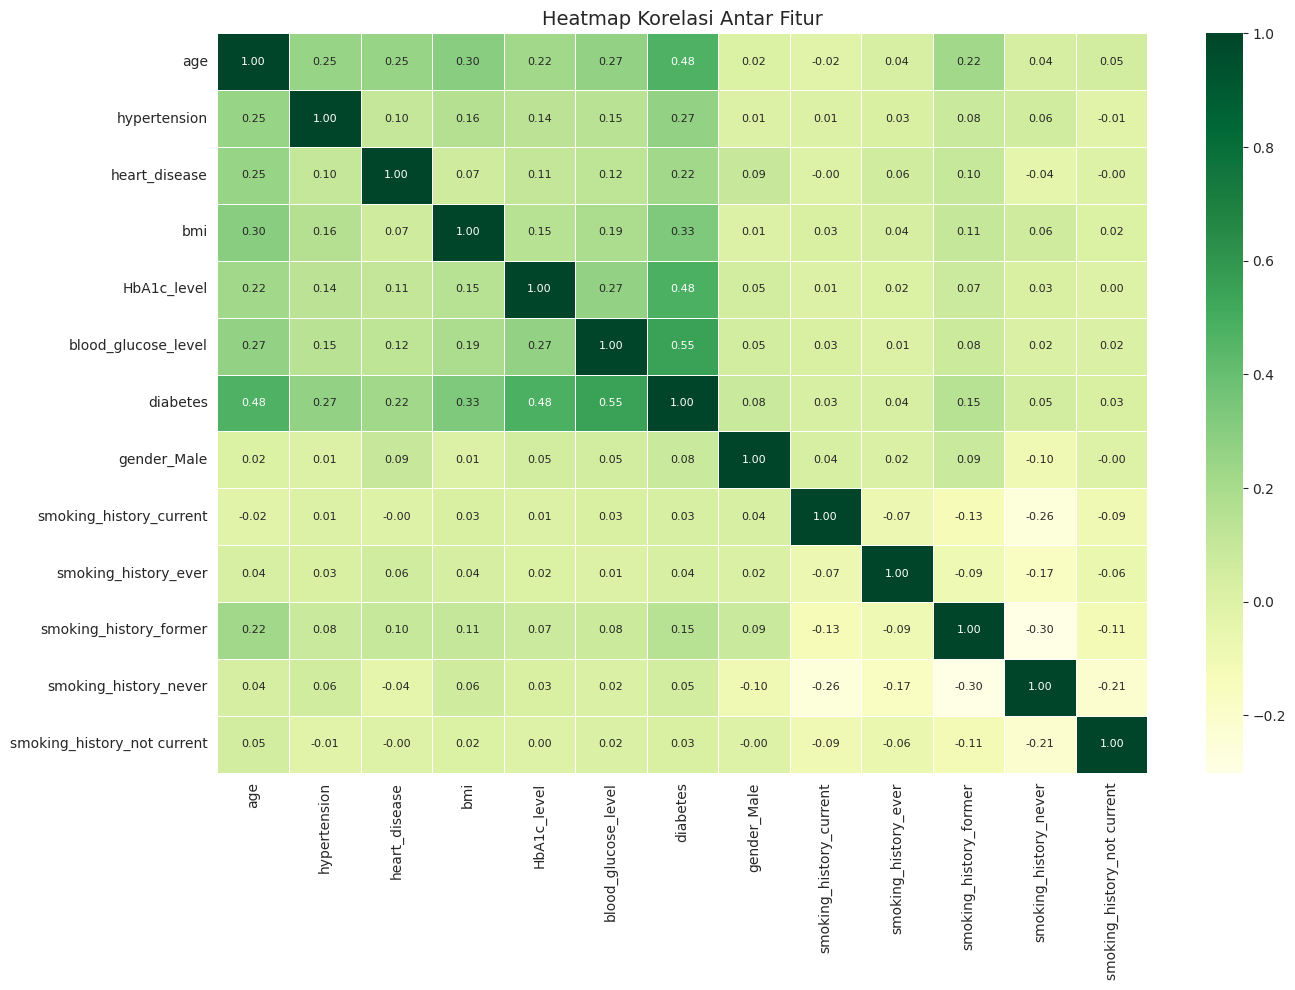

In [105]:
plt.figure(figsize=(14, 10))
corr = df_encoded.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGn',
          linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

## 16. Data Splitting

In [106]:
# Gunakan df_encoded (sudah bersih, seimbang, dan di-encode)
X = df_encoded.drop(columns=['diabetes'])
y = df_encoded['diabetes']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nFitur yang digunakan: {X.columns.tolist()}')

Shape X: (12680, 12)
Shape y: (12680,)

Fitur yang digunakan: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


In [107]:
# Satu split yang konsisten (80:20) dengan stratify untuk menjaga rasio kelas tetap 50:50
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Data latih : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Data uji   : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.0f}%)')

Data latih : 10144 sampel (80%)
Data uji   : 2536 sampel (20%)


## 17. Data Scaling

In [108]:
sc = StandardScaler()

# Fit dan transform HANYA pada data latih untuk mencegah kebocoran data (data leakage)
X_train_sc = sc.fit_transform(X_train)

# Transform saja pada data uji menggunakan pola yang dipelajari dari data latih
X_test_sc = sc.transform(X_test)

print('Scaling selesai.')

Scaling selesai.


## 18. Modeling

In [109]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc, y_train)
print('Model Logistic Regression berhasil dilatih.')

Model Logistic Regression berhasil dilatih.


---
## PHASE 5 — EVALUATION

> *Mengevaluasi model secara menyeluruh untuk memastikan kualitas dan kesiapannya sebelum deployment.*

**Langkah-langkah dalam fase ini:**
- Akurasi model pada data test
- Confusion Matrix — visualisasi True/False Positive dan Negative
- Classification Report — Precision, Recall, F1-Score per kelas
- ROC Curve dan AUC Score — kemampuan diskriminasi model
- 5-Fold Cross-Validation — uji stabilitas dan generalisasi model
- Feature Importance — fitur paling berpengaruh terhadap klasifikasi
- Ringkasan evaluasi model


## 19. Akurasi

In [110]:
y_pred      = log_reg.predict(X_test_sc)
y_pred_prob = log_reg.predict_proba(X_test_sc)[:, 1]  # Probabilitas untuk kelas positif (Diabetes)

acc = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {acc:.4f} ({acc*100:.2f}%)')


Accuracy: 0.8458 (84.58%)


## 20. Confusion Matrix

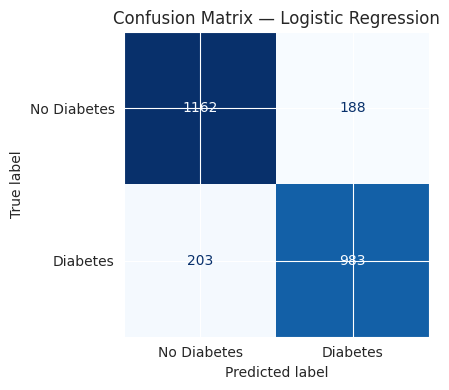

True Negative  (TN) - Sehat ditebak Sehat     : 1162
False Positive (FP) - Sehat ditebak Diabetes  : 188
False Negative (FN) - Diabetes ditebak Sehat  : 203
True Positive  (TP) - Diabetes ditebak Diabetes: 983


In [111]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (TN) - Sehat ditebak Sehat     : {tn}')
print(f'False Positive (FP) - Sehat ditebak Diabetes  : {fp}')
print(f'False Negative (FN) - Diabetes ditebak Sehat  : {fn}')
print(f'True Positive  (TP) - Diabetes ditebak Diabetes: {tp}')

## 21. Classification Report

In [112]:
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))


=== Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.85      0.86      0.86      1350
    Diabetes       0.84      0.83      0.83      1186

    accuracy                           0.85      2536
   macro avg       0.85      0.84      0.85      2536
weighted avg       0.85      0.85      0.85      2536



## 22. ROC_AUC

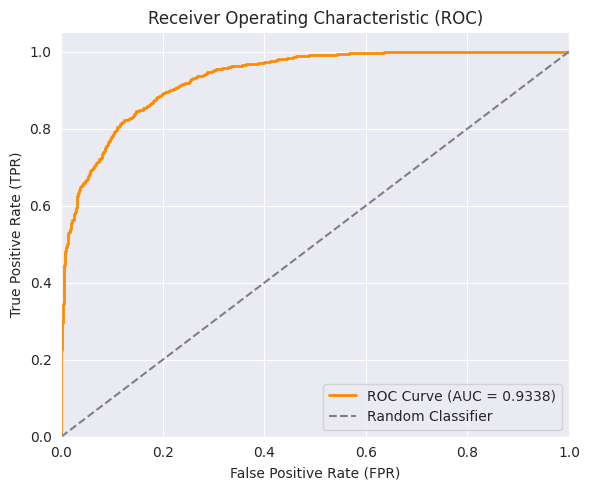

AUC-ROC Score: 0.9338


In [113]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
       label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'AUC-ROC Score: {roc_auc:.4f}')

## 23. Proses validasi dengan 5-Fold Cross-Validation

=== Proses 5-Fold Cross-Validation ===
ACCURACY  : 0.8562 ± 0.0046  (fold: [np.float64(0.86), np.float64(0.8612), np.float64(0.8569), np.float64(0.8482), np.float64(0.8549)])
PRECISION : 0.8508 ± 0.0076  (fold: [np.float64(0.8559), np.float64(0.862), np.float64(0.8508), np.float64(0.842), np.float64(0.8431)])
RECALL    : 0.8399 ± 0.0054  (fold: [np.float64(0.8422), np.float64(0.8373), np.float64(0.8415), np.float64(0.8314), np.float64(0.8474)])
F1        : 0.8453 ± 0.0046  (fold: [np.float64(0.849), np.float64(0.8494), np.float64(0.8461), np.float64(0.8367), np.float64(0.8452)])
ROC_AUC   : 0.9403 ± 0.0035  (fold: [np.float64(0.9458), np.float64(0.9425), np.float64(0.9395), np.float64(0.9362), np.float64(0.9375)])


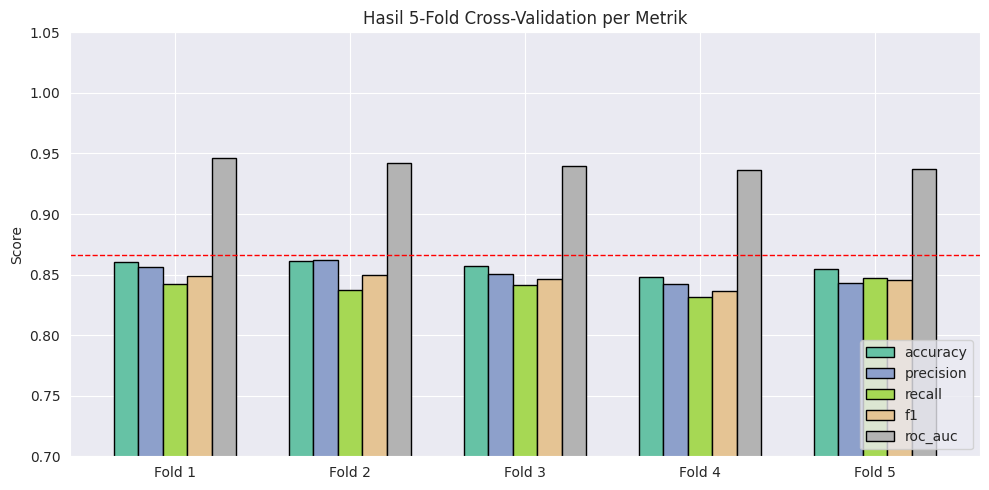

In [114]:
from sklearn.pipeline import Pipeline

# Pipeline agar scaling tidak bocor ke fold validasi
pipeline = Pipeline([
  ('scaler', StandardScaler()),
  ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# StratifiedKFold untuk memastikan setiap fold memiliki rasio kelas target yang sama (50:50)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_dict = {}
print('=== Proses 5-Fold Cross-Validation ===')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
  scores = cross_val_score(pipeline, X, y, cv=skf, scoring=metric)
  metrics_dict[metric] = scores
  print(f'{metric.upper():10s}: {scores.mean():.4f} ± {scores.std():.4f}  '
        f'(fold: {[round(s,4) for s in scores]})')

# Visualisasi hasil cross-validation
cv_df = pd.DataFrame(metrics_dict)

fig, ax = plt.subplots(figsize=(10, 5))
cv_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.7)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)], rotation=0)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.05)
ax.set_title('Hasil 5-Fold Cross-Validation per Metrik')
ax.legend(loc='lower right')
ax.axhline(y=cv_df.mean().mean(), color='red', linestyle='--', linewidth=1,
         label='Rata-rata keseluruhan')
plt.tight_layout()
plt.show()

## 24. Feature Importance

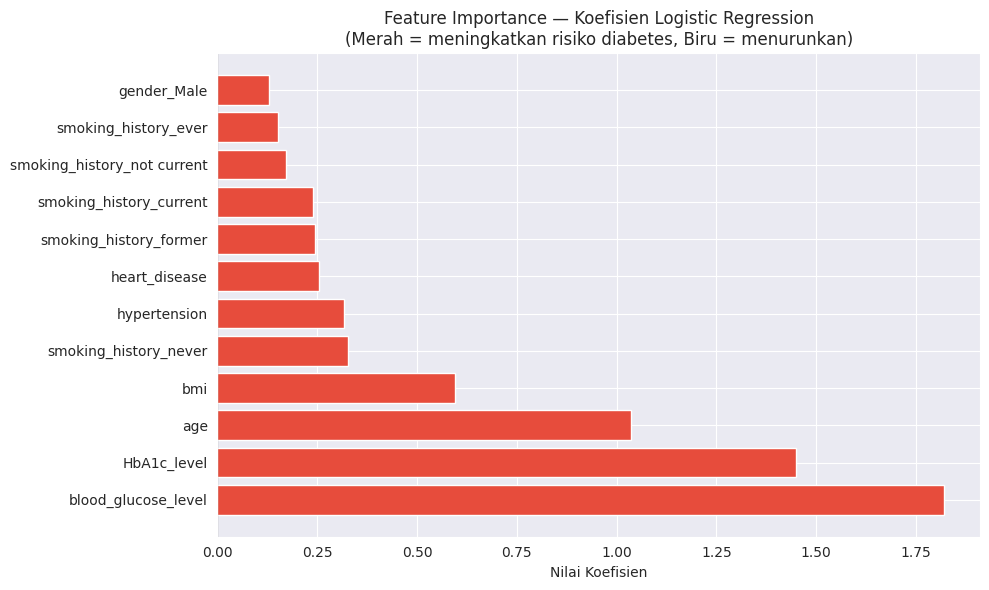

Tabel Koefisien:
                      Fitur  Koefisien
        blood_glucose_level   1.819429
                HbA1c_level   1.449371
                        age   1.037083
                        bmi   0.594312
      smoking_history_never   0.326738
               hypertension   0.316000
              heart_disease   0.253846
     smoking_history_former   0.243239
    smoking_history_current   0.238946
smoking_history_not current   0.171376
       smoking_history_ever   0.152326
                gender_Male   0.128793


In [115]:
# Mengekstrak koefisien dari model Logistic Regression
coef_df = pd.DataFrame({
  'Fitur': X.columns,
  'Koefisien': log_reg.coef_[0]
}).sort_values('Koefisien', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Nilai Koefisien')
plt.title('Feature Importance — Koefisien Logistic Regression\n'
        '(Merah = meningkatkan risiko diabetes, Biru = menurunkan)')
plt.tight_layout()
plt.show()

print("Tabel Koefisien:")
print(coef_df.to_string(index=False))

## 25. Ringkasan Evaluasi Model

In [116]:
from sklearn.metrics import accuracy_score, roc_auc_score

print('=' * 55)
print('       RINGKASAN EVALUASI MODEL LOGISTIC REGRESSION')
print('=' * 55)
print(f'  Dataset (setelah cleaning)  : {len(data_clean)} sampel')
print(f'  Jumlah fitur                : {X.shape[1]}')
print(f'  Split (train/test)          : 80% / 20%')
print('-' * 55)
# Pastikan variabel y_test, y_pred, y_pred_prob sudah di-generate dari tahap sebelumnya
print(f'  Accuracy  (test set)        : {accuracy_score(y_test, y_pred):.4f}')
print(f'  AUC-ROC   (test set)        : {roc_auc_score(y_test, y_pred_prob):.4f}')
print('-' * 55)
print('  5-Fold Cross-Validation:')
for metric, scores in metrics_dict.items():
  print(f'    {metric.upper():10s}: {scores.mean():.4f} ± {scores.std():.4f}')
print('=' * 55)

       RINGKASAN EVALUASI MODEL LOGISTIC REGRESSION
  Dataset (setelah cleaning)  : 12680 sampel
  Jumlah fitur                : 12
  Split (train/test)          : 80% / 20%
-------------------------------------------------------
  Accuracy  (test set)        : 0.8458
  AUC-ROC   (test set)        : 0.9338
-------------------------------------------------------
  5-Fold Cross-Validation:
    ACCURACY  : 0.8562 ± 0.0046
    PRECISION : 0.8508 ± 0.0076
    RECALL    : 0.8399 ± 0.0054
    F1        : 0.8453 ± 0.0046
    ROC_AUC   : 0.9403 ± 0.0035


---
## PHASE 6 — DEPLOYMENT

> *Mengorganisasikan hasil penemuan dan menyebarkan model ke lingkungan produksi.*

**Langkah-langkah dalam fase ini:**
- Simpan model, scaler, dan nama fitur ke file `.pkl` menggunakan `joblib`
- Load model yang telah disimpan dan lakukan klasifikasi pada data pasien baru
- Contoh klasifikasi satu pasien dan batch pasien dari file CSV


## 26. Simpan Model

In [117]:
import joblib

# Simpan model, scaler, dan daftar fitur ke dalam file
joblib.dump(log_reg, 'model_diabetes_balanced.pkl')
joblib.dump(sc, 'scaler_diabetes_balanced.pkl')
joblib.dump(list(X.columns), 'features_diabetes_balanced.pkl')  # simpan nama kolom

print(' Model (Balanced)  → model_diabetes_balanced.pkl')
print(' Scaler            → scaler_diabetes_balanced.pkl')
print(' Fitur             → features_diabetes_balanced.pkl')
print('\nProses penyimpanan berhasil. Model siap diimplementasikan ke dalam aplikasi web!')

 Model (Balanced)  → model_diabetes_balanced.pkl
 Scaler            → scaler_diabetes_balanced.pkl
 Fitur             → features_diabetes_balanced.pkl

Proses penyimpanan berhasil. Model siap diimplementasikan ke dalam aplikasi web!


## 26. Load Model dan Klasifikasi Data Baru

In [118]:
# Load model, scaler, dan nama fitur (menggunakan versi balanced)
model    = joblib.load('model_diabetes_balanced.pkl')
scaler   = joblib.load('scaler_diabetes_balanced.pkl')
features = joblib.load('features_diabetes_balanced.pkl')

print(f'Model berhasil di-load: {type(model).__name__}')
print(f'Fitur yang dibutuhkan ({len(features)}): {features}')


#  Contoh Klasifikasi 1 pasien baru 

pasien_baru = {
  'age'                         : 55,
  'hypertension'                 : 1,
  'heart_disease'                : 0,
  'bmi'                          : 29.4,
  'HbA1c_level'                  : 7.2,
  'blood_glucose_level'          : 155,
  'gender_Male'                  : 1,   # 1 = laki-laki, 0 = perempuan
  'smoking_history_ever'         : 0,
  'smoking_history_former'       : 0,
  'smoking_history_never'        : 1,
  'smoking_history_not current'  : 0,
  'smoking_history_current'      : 0,
}

df_pasien    = pd.DataFrame([pasien_baru])
# reindex akan mencocokkan kolom dengan urutan saat training dan mengisi fitur kategori yang tidak ada dengan 0
df_pasien    = df_pasien.reindex(columns=features, fill_value=0)
df_pasien_sc = scaler.transform(df_pasien)

Klasifikasi     = model.predict(df_pasien_sc)[0]
probabilitas = model.predict_proba(df_pasien_sc)[0][1]

print('\n' + '=' * 40)
print('       HASIL Klasifikasi PASIEN')
print('=' * 40)
print(f' Klasifikasi       : {"  DIABETES" if Klasifikasi == 1 else " TIDAK DIABETES"}')
print(f' Probabilitas   : {probabilitas:.2%}')
print(f' Tingkat risiko : {"Tinggi" if probabilitas >= 0.7 else "Sedang" if probabilitas >= 0.4 else "Rendah"}')
print('=' * 40 + '\n')

Model berhasil di-load: LogisticRegression
Fitur yang dibutuhkan (12): ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']

       HASIL Klasifikasi PASIEN
 Klasifikasi       :   DIABETES
 Probabilitas   : 96.10%
 Tingkat risiko : Tinggi



In [119]:
#  Klasifikasi banyak pasien sekaligus (dari DataFrame / CSV) 
# Contoh: load dari file CSV
# df_baru = pd.read_csv('data_pasien_baru.csv')
# df_baru_encoded = pd.get_dummies(df_baru, columns=['gender', 'smoking_history'], drop_first=True)
# df_baru_encoded = df_baru_encoded.reindex(columns=features, fill_value=0)
# df_baru_sc = scaler.transform(df_baru_encoded)
# Klasifikasi_semua = model.predict(df_baru_sc)
# prob_semua     = model.predict_proba(df_baru_sc)[:, 1]
# df_baru['Klasifikasi']     = Klasifikasi_semua
# df_baru['probabilitas'] = prob_semua
# df_baru.head()

print('Uncomment kode di atas dan sesuaikan nama file CSV untuk Klasifikasi batch.')

Uncomment kode di atas dan sesuaikan nama file CSV untuk Klasifikasi batch.
